# Módulo Visualização de Dados:

Leia o arquivo ecommerce_preparados.csv’ dentro de um dataframe  

Faça uma análise detalhada dos dados, descubra quais dados gostaria de destacar e crie os seguintes gráficos:


*   1 Gráfico de dispersão
*   1 Mapa de calor
*   1 Gráfico de barra
*   1 Gráfico de pizza
*   1 Gráfico de densidade

Adicione títulos nos gráficos e nos eixos para ficar claro os objetivos dos gráficos.

Fiquem a vontade para escolher a biblioteca que quiserem, não esqueçam de comentar os códigos.

Essa atividade é um pouco diferente, vocês terão que construir os códigos nesse arquivo e enviar ou o arquivo ou o link do github com o arquivo publicado para os tutores.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, LabelEncoder

1) Análise do DataFrame e tratamento de alguns dados

In [2]:
df = pd.read_csv(r'C:\Users\usuario\Downloads\ecommerce_preparados.csv')

# Mostrar os títulos de cada coluna:
print(df.head(0))

Empty DataFrame
Columns: [Unnamed: 0, Título, Nota, N_Avaliações, Desconto, Marca, Material, Gênero, Temporada, Review1, Review2, Review3, Qtd_Vendidos, Preço, Nota_MinMax, N_Avaliações_MinMax, Desconto_MinMax, Preço_MinMax, Marca_Cod, Material_Cod, Temporada_Cod, Qtd_Vendidos_Cod, Marca_Freq, Material_Freq]
Index: []

[0 rows x 24 columns]


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2199 entries, 0 to 2198
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           2199 non-null   int64  
 1   Título               2199 non-null   object 
 2   Nota                 1559 non-null   float64
 3   N_Avaliações         1559 non-null   float64
 4   Desconto             874 non-null    float64
 5   Marca                2199 non-null   object 
 6   Material             1332 non-null   object 
 7   Gênero               2120 non-null   object 
 8   Temporada            2199 non-null   object 
 9   Review1              1515 non-null   object 
 10  Review2              1354 non-null   object 
 11  Review3              1233 non-null   object 
 12  Qtd_Vendidos         2199 non-null   object 
 13  Preço                1964 non-null   float64
 14  Nota_MinMax          1559 non-null   float64
 15  N_Avaliações_MinMax  1559 non-null   f

In [4]:
# Verificação do total de dados nulos
print(df.isnull().sum())

Unnamed: 0                0
Título                    0
Nota                    640
N_Avaliações            640
Desconto               1325
Marca                     0
Material                867
Gênero                   79
Temporada                 0
Review1                 684
Review2                 845
Review3                 966
Qtd_Vendidos              0
Preço                   235
Nota_MinMax             640
N_Avaliações_MinMax     640
Desconto_MinMax        1325
Preço_MinMax            235
Marca_Cod                 0
Material_Cod              0
Temporada_Cod             0
Qtd_Vendidos_Cod        226
Marca_Freq                0
Material_Freq           867
dtype: int64


In [5]:
# Substituir nulos em Nota_MinMax pela média:
df['Nota_MinMax'] = df['Nota_MinMax'].fillna(df['Nota_MinMax'].mean())

In [6]:
# Conferindo nulos em Nota_MinMax:
print(df['Nota_MinMax'].isnull().sum())

0


In [7]:
# Removendo produtos duplicados:
df.drop_duplicates(subset='Título',inplace=True)

# Renomeando coluna:
df.rename(columns={'Título' : 'Produto'}, inplace=True)

# Removendo colunas não necessárias:
df = df.drop(['Review1','Review2', 'Review3'], axis=1)

In [8]:
print(len(df['Produto'].unique()))

1857


In [9]:
print(df['Preço'].isnull().sum())

212


In [10]:
# Substituindo N/As pela média:
df['Preço'] = df['Preço'].fillna(df['Preço'].mean())
df['Qtd_Vendidos_Cod'] = df['Qtd_Vendidos_Cod'].fillna(df['Qtd_Vendidos_Cod'].mean())
print(df['Preço'].isnull().sum())
print(df['Qtd_Vendidos_Cod'].isnull().sum())

0
0


In [11]:
# Verificação do campo 'Gênero':
print(df['Gênero'].unique())
print(len(df['Gênero'].unique()))

['Sem gênero' 'Masculino' 'Feminino' 'Sem gênero infantil' 'Meninas'
 'Bebês' 'Meninos' nan 'Unissex' 'short menina verao look mulher' 'Mulher'
 'roupa para gordinha pluss P ao 52' 'menino'
 'bermuda feminina brilho Blogueira']
14


In [12]:
# Filtrando os gêneros mais frequentes:
freq = df['Gênero'].value_counts()
print(freq)

Gênero
Feminino                             643
Masculino                            435
Bebês                                273
Sem gênero                           172
Meninas                              106
Meninos                               96
Sem gênero infantil                   51
Mulher                                 3
Unissex                                1
short menina verao look mulher         1
roupa para gordinha pluss P ao 52      1
menino                                 1
bermuda feminina brilho Blogueira      1
Name: count, dtype: int64


In [13]:
acima_4 = freq[freq >= 4].index

df = df[df['Gênero'].isin(acima_4)]

print(df['Gênero'].value_counts())

Gênero
Feminino               643
Masculino              435
Bebês                  273
Sem gênero             172
Meninas                106
Meninos                 96
Sem gênero infantil     51
Name: count, dtype: int64


In [14]:
# Agrupando Qtd_Vendidos_Cod por Gênero:
grupos = df.groupby('Gênero')
vendas_gen = grupos['Qtd_Vendidos_Cod'].sum()
#print(vendas_gen)

In [15]:
df_gen = pd.DataFrame(vendas_gen)
print(df_gen)

                     Qtd_Vendidos_Cod
Gênero                               
Bebês                    80976.755464
Feminino                197690.882457
Masculino               350054.857649
Meninas                  30313.191967
Meninos                  26212.281748
Sem gênero               43963.845245
Sem gênero infantil       5106.730656


In [16]:
# Convertendo a Series df_gen em um DataFrame, em que 'Gênero' passa a ser uma coluna em vez de índice:
df_vendas_gen = df_gen.reset_index()
df_vendas_gen.columns = ['Gênero', 'Total_Vendas']
print(df_vendas_gen)

                Gênero   Total_Vendas
0                Bebês   80976.755464
1             Feminino  197690.882457
2            Masculino  350054.857649
3              Meninas   30313.191967
4              Meninos   26212.281748
5           Sem gênero   43963.845245
6  Sem gênero infantil    5106.730656


In [17]:
# Codificando a coluna Gêneros:
df['Genero_cod'] = df['Gênero'].astype('category').cat.codes
#print(f"\n Categorias Gêneros:\n {df['generos_cod'].astype('category')}")

# Codificando a coluna Produto:
df['Produto_cod'] = df['Produto'].astype('category').cat.codes


In [18]:
# Filtrando Marcas para encontrar as mais vendidas:

grupo_marcas = df.groupby('Marca')
vendas_marca = grupo_marcas['Qtd_Vendidos_Cod'].sum()

print(vendas_marca.head())

Marca
4 estações                         25.0
a sorriso baby confecções ltda    100.0
a. a.j.sport                        5.0
a.a.j.sport                       185.0
a.c kids                            5.0
Name: Qtd_Vendidos_Cod, dtype: float64


In [19]:
top_marcas = vendas_marca.nlargest(10)
print(top_marcas)

Marca
lupo               74651.551093
zorba              63770.910219
moda llevo         50435.910219
zaroc              50435.910219
mash               25890.730656
elite              20006.000000
stillger jeans     16202.730656
imperio kids       13487.730656
multimarcas        13208.910219
batutinhas baby    12635.910219
Name: Qtd_Vendidos_Cod, dtype: float64


In [20]:
# Transformando top_marcas em DF:
df_marcas = pd.DataFrame(top_marcas)
df_marcas = df_marcas.reset_index()
df_marcas.columns = ['Marca', 'Total_Vendas']
df_marcas['Total_Vendas'] = df_marcas['Total_Vendas'].astype(int)
print(df_marcas)


             Marca  Total_Vendas
0             lupo         74651
1            zorba         63770
2       moda llevo         50435
3            zaroc         50435
4             mash         25890
5            elite         20006
6   stillger jeans         16202
7     imperio kids         13487
8      multimarcas         13208
9  batutinhas baby         12635


In [21]:
# Preenchendo NaN das Notas com a média:
df['Nota'] = df['Nota'].fillna(df["Nota"].mean())

In [22]:
print(df.head(0))

Empty DataFrame
Columns: [Unnamed: 0, Produto, Nota, N_Avaliações, Desconto, Marca, Material, Gênero, Temporada, Qtd_Vendidos, Preço, Nota_MinMax, N_Avaliações_MinMax, Desconto_MinMax, Preço_MinMax, Marca_Cod, Material_Cod, Temporada_Cod, Qtd_Vendidos_Cod, Marca_Freq, Material_Freq, Genero_cod, Produto_cod]
Index: []

[0 rows x 23 columns]


2) Gráficos:


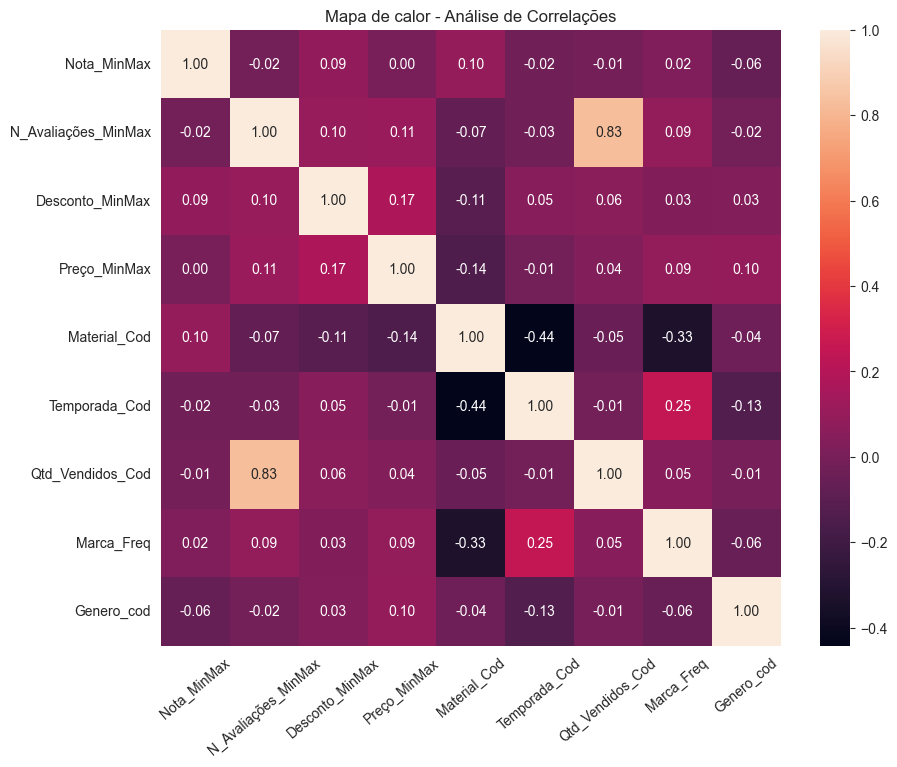

In [23]:
# Mapa de calor para analisar correlações:
df_corr = df[['Nota_MinMax', 'N_Avaliações_MinMax', 'Desconto_MinMax', 'Preço_MinMax', 'Material_Cod', 'Temporada_Cod', 'Qtd_Vendidos_Cod', 'Marca_Freq', 'Genero_cod']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(data=df_corr, annot=True, fmt='.2f')
plt.title('Mapa de calor - Análise de Correlações')
plt.xticks(rotation=40)
plt.show()

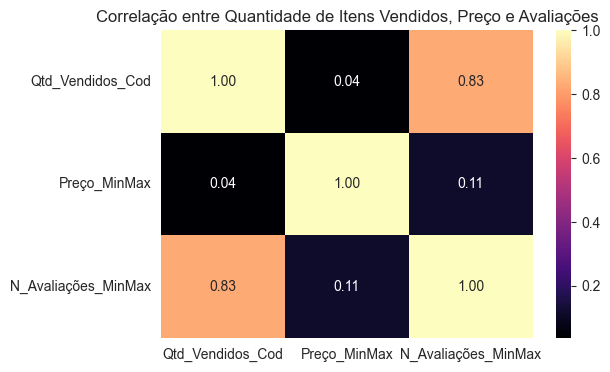

In [24]:
# Correlação entre Vendas, Preço, e Avaliações:
df_corr_vpa = df[['Qtd_Vendidos_Cod', 'Preço_MinMax', 'N_Avaliações_MinMax']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(data=df_corr_vpa, annot=True, fmt='.2f', cmap='magma')
plt.title('Correlação entre Quantidade de Itens Vendidos, Preço e Avaliações')
plt.show()

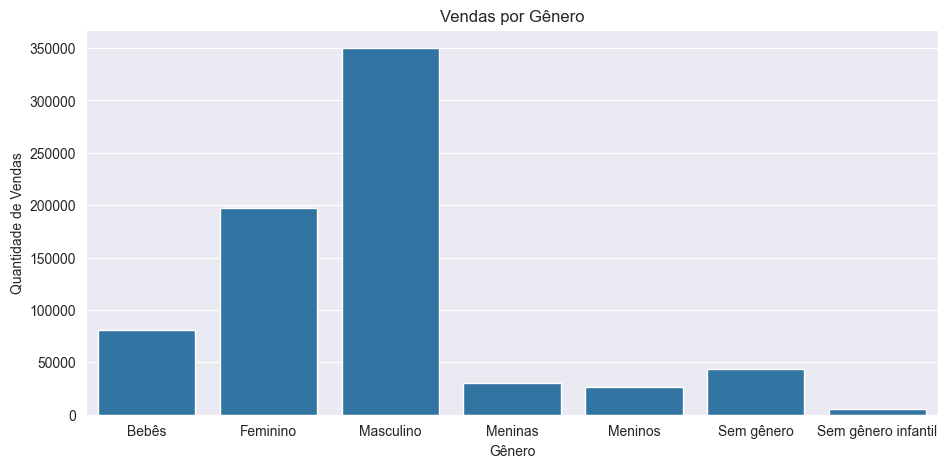

In [25]:
# Gráfico de Barras: Gênero x Qtd_Vendidos_Cod
# Análise das vendas segundo o gênero dos produtos
plt.figure(figsize=(11, 5))
sns.barplot(data=df_vendas_gen, x='Gênero', y='Total_Vendas')
plt.title('Vendas por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Vendas')
plt.show()

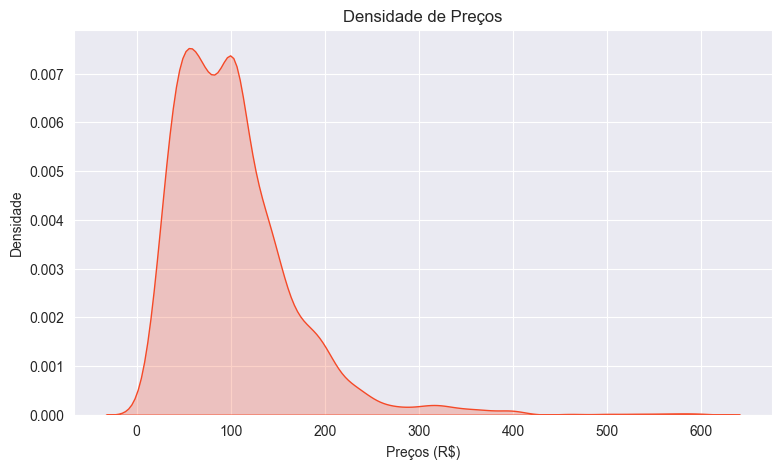

In [26]:
# Densidade: Análise da variação de preços
plt.figure(figsize=(9, 5))
sns.kdeplot(df['Preço'], fill=True, color='#f54927')
plt.title('Densidade de Preços')
plt.xlabel('Preços (R$)')
plt.ylabel('Densidade')
plt.show()


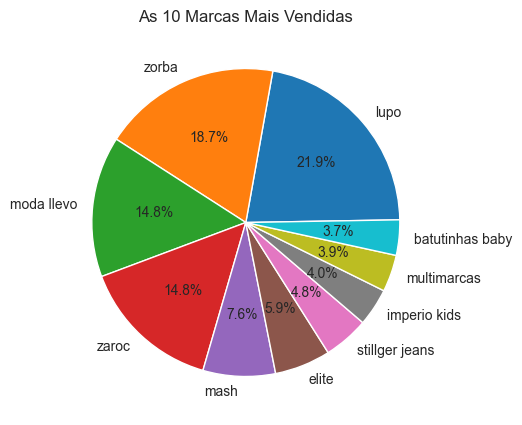

In [27]:
# Pizza: Participação de marcas no catálogo
x = df_marcas['Marca']
y = df_marcas['Total_Vendas']
plt.figure(figsize=(8, 5))
plt.pie(y, labels=x, autopct='%.1f%%', startangle=1)
plt.title('As 10 Marcas Mais Vendidas')
plt.show()

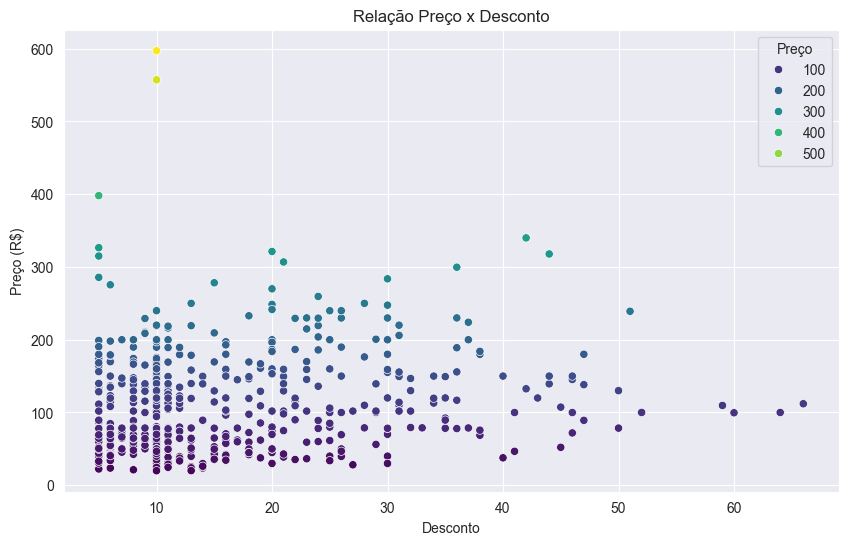

In [28]:
# Dispersão: Desconto x Preço
# Verificação dos descontos concedidos em relação aos preços de venda
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Desconto', y='Preço', hue='Preço', data=df, palette='viridis')
plt.title('Relação Preço x Desconto')
plt.xlabel('Desconto')
plt.ylabel('Preço (R$)')
plt.show()


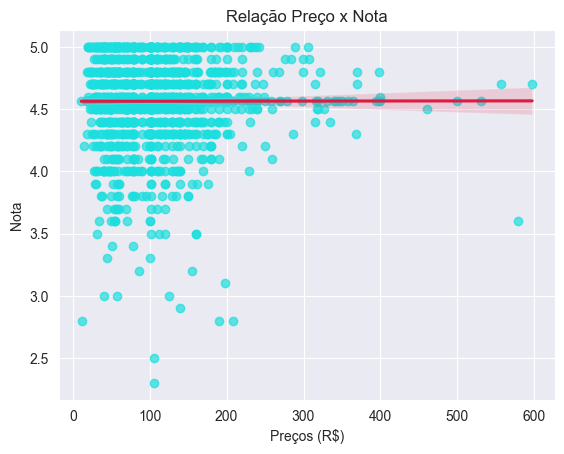

In [38]:
# Regressão: Verificação se produtos mais baratos tendem a ter notas mais baixas
sns.regplot(x = 'Preço', y = 'Nota', data=df, color='#de1b42', scatter_kws={'alpha': 0.7, 'color':'#1bdede'})
plt.title('Relação Preço x Nota')
plt.xlabel('Preços (R$)')
plt.ylabel('Nota')
plt.show()

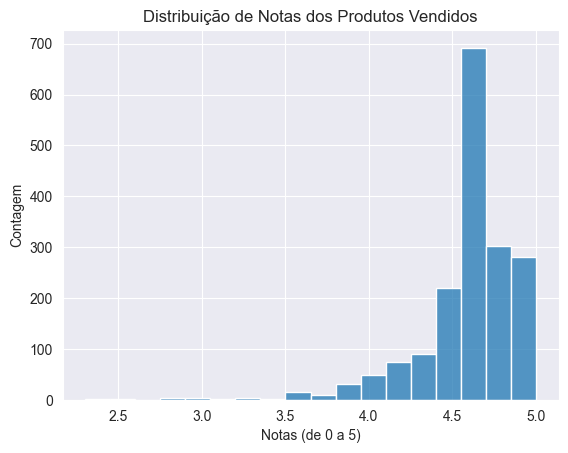

In [34]:
# Histograma
sns.histplot(x='Nota', data=df, binwidth=0.15)
plt.title('Distribuição de Notas dos Produtos Vendidos')
plt.xlabel('Notas (de 0 a 5)')
plt.ylabel('Contagem')
plt.show()